In [104]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.metrics import silhouette_score

In [105]:
df=pd.read_csv('../data/cleaned_crime_records.csv')
df= df.sample(n=500000, random_state=42)

In [106]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

X = df[['Latitude','Longitude']]
X = X.astype('float32')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [107]:
kmeans = KMeans(n_clusters=7, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

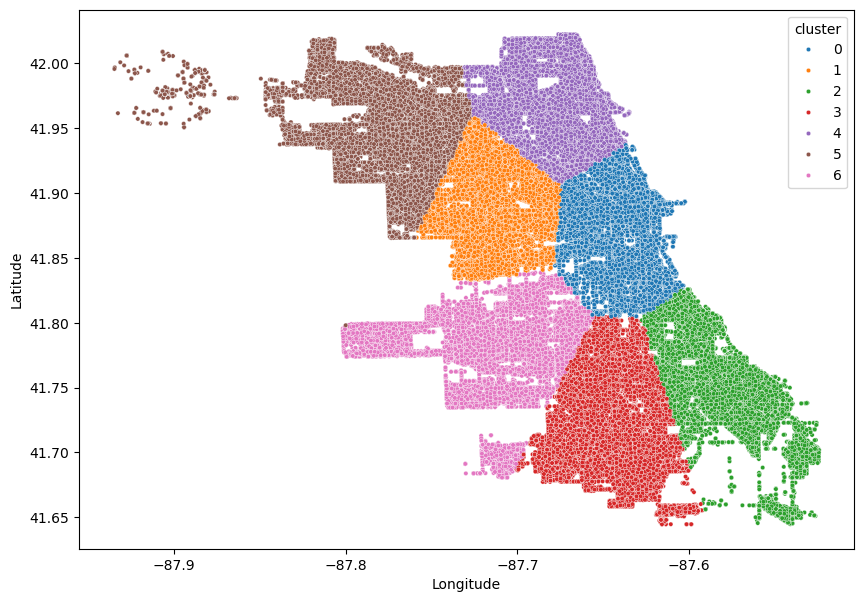

In [108]:
plt.figure(figsize=(10,7))
sns.scatterplot(
x=df['Longitude'],
y=df['Latitude'],
hue=df['cluster'],
palette='tab10',
s=10
)
plt.show()

In [109]:
cluster_sizes = df['cluster'].value_counts().reset_index()
cluster_sizes.columns = ['cluster', 'size']

df = df.merge(cluster_sizes, on='cluster')

In [142]:
from shapely.geometry import MultiPoint
import geopandas as gpd

polygons = []

for cluster_id, group in df[df['cluster'] != -1].groupby('cluster'):
    points = list(zip(group['Longitude'], group['Latitude']))
    
    if len(points) > 2:
        hull = MultiPoint(points).convex_hull
        polygons.append({
            'cluster': cluster_id,
            'size': len(points),
            'geometry': hull
        })

gdf = gpd.GeoDataFrame(polygons, crs="EPSG:4326")
gdf.to_file("../data/crime_hotspots.geojson", driver="GeoJSON")

In [111]:
geojson = gdf.__geo_interface__

import plotly.express as px
import plotly.io as pio

# pio.renderers.default = "notebook_connected"
pio.renderers.default = "browser"

fig = px.choropleth_mapbox(
    gdf,
    geojson=geojson,
    locations=gdf.index,
    color='size',
    color_continuous_scale=["green", "yellow", "red"],  # 🔥 your requirement
    mapbox_style="open-street-map",
    center={
        "lat": df["Latitude"].mean(),
        "lon": df["Longitude"].mean()
    },
    zoom=9,
    opacity=0.5
)

fig.show()

/var/folders/33/6j7x5yjn4vs9rpp5_xx32x740000gn/T/ipykernel_16375/2477501233.py:9: DeprecationWarning: *choropleth_mapbox* is deprecated! Use *choropleth_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.choropleth_mapbox(


In [112]:
def load_temporal_features(df):
    day_map={
        'Sunday':0,
        'Monday':1,
        'Tuesday':2,
        'Wednesday':3,
        'Thursday':4,
        'Friday':5,
        'Saturday':6,
    }
    df['day']=df['day'].replace(day_map)
    temp_features = df[['hour', 'day', 'month']]
    return temp_features
def scale_features(temp_features):
    X = temp_features
    X = X.astype('float32')

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

temp_features=load_temporal_features(df)
X_scaled=scale_features(temp_features)

In [113]:
kmeans_time = KMeans(n_clusters=4)
df['time_cluster'] = kmeans_time.fit_predict(temp_features)

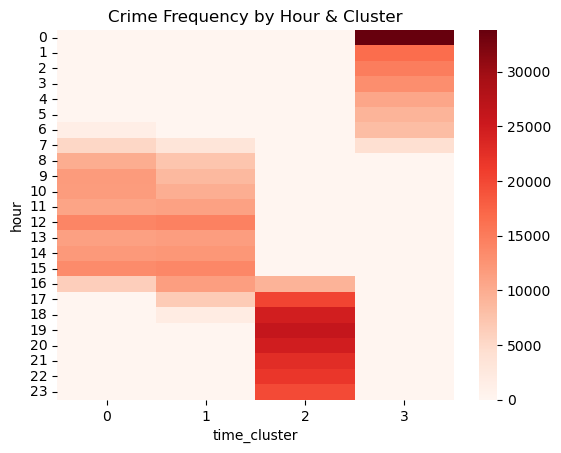

In [114]:
pivot = df.pivot_table(index='hour', columns='time_cluster', aggfunc='size', fill_value=0)

sns.heatmap(pivot, cmap="Reds")
plt.title("Crime Frequency by Hour & Cluster")
plt.show()

In [ ]:
=(df['size'].max())

np.int64(98134)

In [129]:
df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,District,Ward,Community Area,Latitude,Longitude,hour,day,month,year,weekend,cluster,size,time_cluster
0,13986460,2025-10-01 20:30:00,BATTERY,DOMESTIC BATTERY SIMPLE,STREET,False,True,15,37.0,25.0,41.880368,-87.755370,20,3,10,2025,False,5,49991,2
1,13838422,2025-05-17 06:50:00,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,17,39.0,13.0,41.983649,-87.716222,6,6,5,2025,True,4,65663,3
2,13929304,2025-08-09 16:32:00,NARCOTICS,POSSESS - CANNABIS MORE THAN 30 GRAMS,STREET,True,False,3,7.0,43.0,41.759814,-87.571246,16,6,8,2025,True,2,79721,2
3,14019859,2025-08-20 15:30:00,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,BANK,False,False,22,19.0,72.0,41.720967,-87.680207,15,3,8,2025,False,3,73943,0
4,13521832,2024-07-07 16:30:00,ASSAULT,"PROTECTED EMPLOYEE - HANDS, FISTS, FEET, NO / ...",GAS STATION,False,False,3,5.0,43.0,41.772999,-87.576479,16,0,7,2024,True,2,79721,2


In [132]:
ls=df[(df['cluster']==(df['cluster'].value_counts().reset_index().index[0]))]['District'].unique()

In [138]:
df['Arrest'].value_counts()

Arrest
False    424844
True      75156
Name: count, dtype: int64

In [143]:
df.columns

Index(['ID', 'Date', 'Primary Type', 'Description', 'Location Description',
       'Arrest', 'Domestic', 'District', 'Ward', 'Community Area', 'Latitude',
       'Longitude', 'hour', 'day', 'month', 'year', 'weekend', 'cluster',
       'size', 'time_cluster'],
      dtype='str')

In [136]:
for l in ls:
    print(l)

1
18
12
2
9
19
14
10


In [117]:
df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,District,Ward,Community Area,Latitude,Longitude,hour,day,month,year,weekend,cluster,size,time_cluster
0,13986460,2025-10-01 20:30:00,BATTERY,DOMESTIC BATTERY SIMPLE,STREET,False,True,15,37.0,25.0,41.880368,-87.755370,20,3,10,2025,False,5,49991,2
1,13838422,2025-05-17 06:50:00,BATTERY,DOMESTIC BATTERY SIMPLE,APARTMENT,False,True,17,39.0,13.0,41.983649,-87.716222,6,6,5,2025,True,4,65663,3
2,13929304,2025-08-09 16:32:00,NARCOTICS,POSSESS - CANNABIS MORE THAN 30 GRAMS,STREET,True,False,3,7.0,43.0,41.759814,-87.571246,16,6,8,2025,True,2,79721,2
3,14019859,2025-08-20 15:30:00,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,BANK,False,False,22,19.0,72.0,41.720967,-87.680207,15,3,8,2025,False,3,73943,0
4,13521832,2024-07-07 16:30:00,ASSAULT,"PROTECTED EMPLOYEE - HANDS, FISTS, FEET, NO / ...",GAS STATION,False,False,3,5.0,43.0,41.772999,-87.576479,16,0,7,2024,True,2,79721,2


In [139]:
df.to_csv('../data/clustered_data.csv',index=False)

In [140]:
cd=pd.read_csv('../data/clustered_data.csv')

In [141]:
cd.columns

Index(['ID', 'Date', 'Primary Type', 'Description', 'Location Description',
       'Arrest', 'Domestic', 'District', 'Ward', 'Community Area', 'Latitude',
       'Longitude', 'hour', 'day', 'month', 'year', 'weekend', 'cluster',
       'size', 'time_cluster'],
      dtype='str')